# Data Analyst Job Market Analysis

## Introduction

### Goal
1. Investigate top-paying roles and skills in the data science industry.
2. Use Python to explore a real-live dataset on job postings.
3. For job-seekers: use these insights to help find the best job opportunities.
### Dataset
This project uses a dataset of job postings to analyze salaries, required skills, and demand for Data Analyst roles in the United States.

### Questions
1. What are the most demanded skills for the top 3 most popular data roles?
2. How are in-demand skills trending for Data Analysts?
3. How well do jobs and skills pay for Data Analysts?
4. What is the most optimal skill to learn for Data Analysts?


# Exploratory Data Analysis for all Data Roles
### Roles to Explore

In [3]:
# Importing Libraries
import ast
import pandas as pd
import seaborn as sns
from datasets import load_dataset
import matplotlib.pyplot as plt  

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

c:\Users\LLP\anaconda3\envs\Python_Project\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


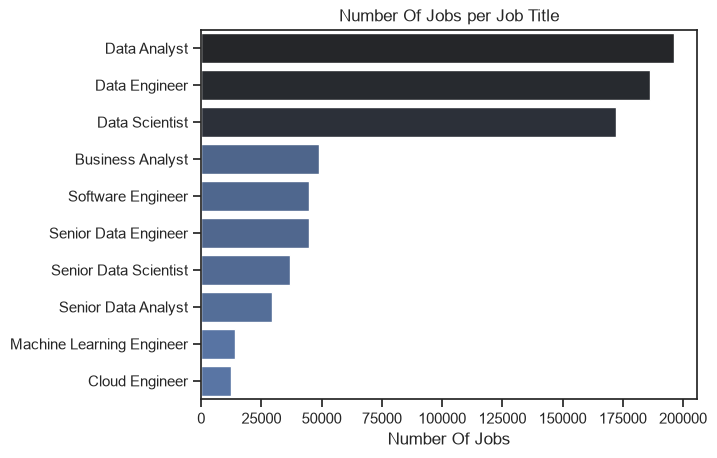

In [34]:
df_plot = df['job_title_short'].value_counts().to_frame()
sns.set_theme(style='ticks')
sns.barplot(data=df_plot, x='count', y='job_title_short', hue='count', palette='dark:b_r', legend=False)
plt.title('Number Of Jobs per Job Title')
plt.xlabel('Number Of Jobs')
plt.ylabel('')
plt.show()

### Countries to Explore

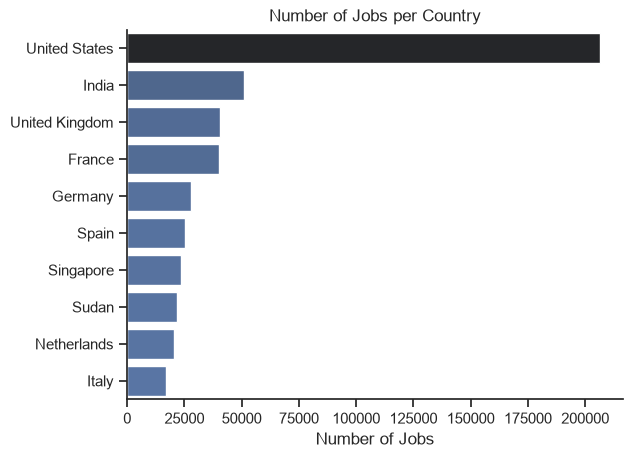

In [43]:
df_plot=df['job_country'].value_counts().head(10).to_frame()
sns.set_theme(style='ticks')
sns.barplot(data=df_plot, x='count', y='job_country', hue='count', palette='dark:b_r', legend=False)
sns.despine()
plt.title('Number of Jobs per Country')
plt.xlabel('Number of Jobs')
plt.ylabel('')
plt.show()

### Companies to Explore

Text(0, 0.5, '')

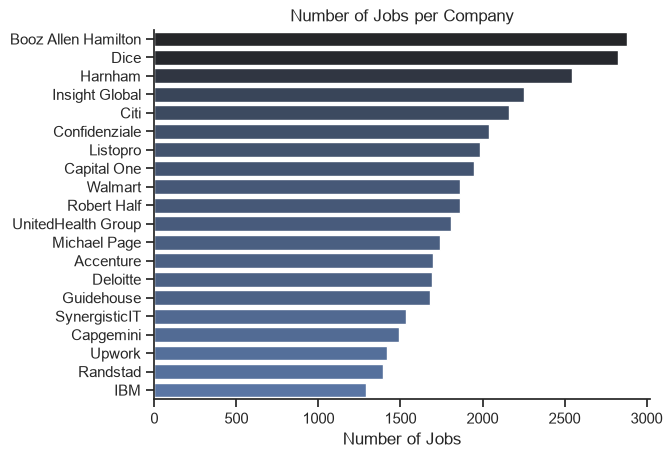

In [54]:
df_plot = df['company_name'].value_counts().to_frame()[1:].head(20)
sns.set_theme(style='ticks')
sns.barplot(data=df_plot, x='count', y='company_name', hue='count', palette='dark:b_r', legend=False)
sns.despine()
plt.title('Number of Jobs per Company')
plt.xlabel('Number of Jobs')
plt.ylabel('')

### Job Opportunities

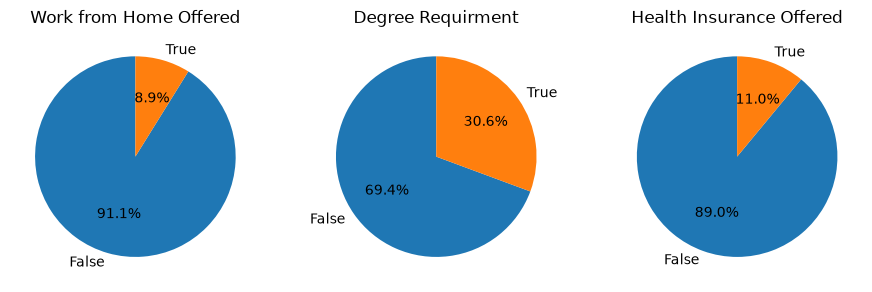

In [6]:
dic_column={
    'job_work_from_home': 'Work from Home Offered',
    'job_no_degree_mention': 'Degree Requirment',
    'job_health_insurance': 'Health Insurance Offered'
}

fig, ax= plt.subplots(1, 3, figsize=(11, 3.5))
for i, (col, title) in enumerate(dic_column.items()):
    ax[i].pie(df[col].value_counts(), labels=[False, True], autopct='%1.1f%%', startangle=90)
    ax[i].set_title(title)

## Exploratory Data Analysis for Data Analysts in the US

### Filter for US Data Analyst roles

In [7]:
df_DA_US = df[(df['job_country']=='United States') & (df['job_title_short']=='Data Analyst')]

In [8]:
df_DA_US.head(3)

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
36,Data Analyst,Data Analyst,"Des Moines, IA",via Trabajo.org,Full-time,False,"Illinois, United States",2023-11-06 13:01:22,False,True,United States,NaN,NaN,NaN,Assuredpartners,NaN,NaN
68,Data Analyst,Sr. Research Data Analyst,"Baltimore, MD",via ZipRecruiter,Full-time,False,"New York, United States",2023-03-24 13:01:00,False,False,United States,NaN,NaN,NaN,Johns Hopkins Medicine,"[r, zoom]","{'programming': ['r'], 'sync': ['zoom']}"
73,Data Analyst,Entry level / Systems Data Analyst (Remote),Anywhere,via LinkedIn,Contractor,True,"Illinois, United States",2023-06-16 13:18:22,True,True,United States,NaN,NaN,NaN,Soft Magic,"[word, excel, powerpoint, outlook]","{'analyst_tools': ['word', 'excel', 'powerpoin..."


### Locations to Explore:

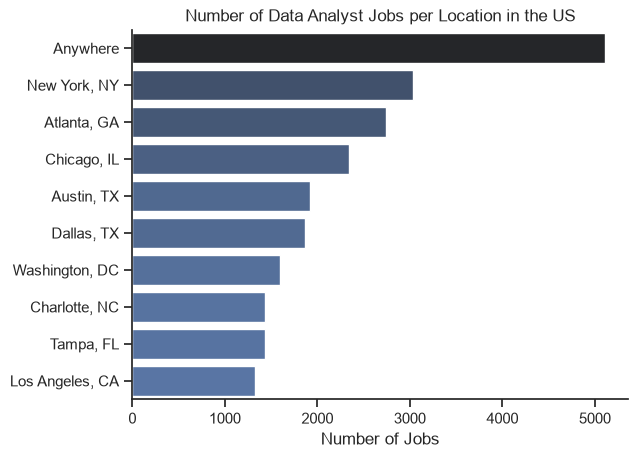

In [11]:
df_plot = df_DA_US['job_location'].value_counts().head(10).to_frame()

sns.set_theme(style='ticks')
sns.barplot(data=df_plot, x='count', y='job_location', hue='count', palette='dark:b_r', legend=False)
sns.despine()
plt.title('Number of Data Analyst Jobs per Location in the US')
plt.xlabel('Number of Jobs')
plt.ylabel('')
plt.show()

### Job Opportunities

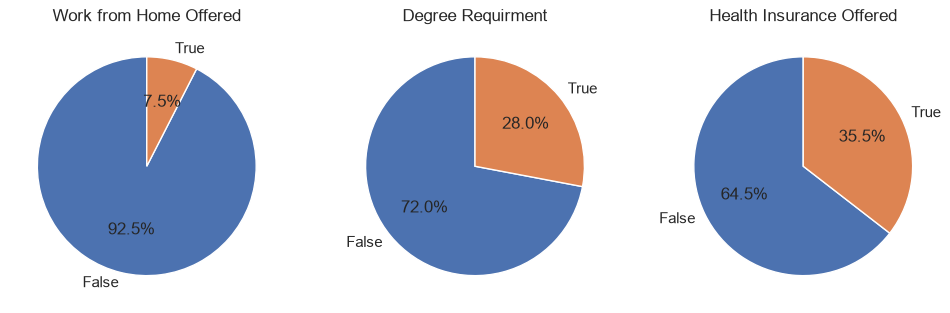

In [14]:
dic_column={
    'job_work_from_home': 'Work from Home Offered',
    'job_no_degree_mention': 'Degree Requirment',
    'job_health_insurance': 'Health Insurance Offered'
}

fig, ax= plt.subplots(1, 3)
fig.set_size_inches(12, 5)
for i, (col, title) in enumerate(dic_column.items()):
    ax[i].pie(df_DA_US[col].value_counts(), labels=[False, True], autopct='%1.1f%%', startangle=90)
    ax[i].set_title(title)

### Companies to Explore:

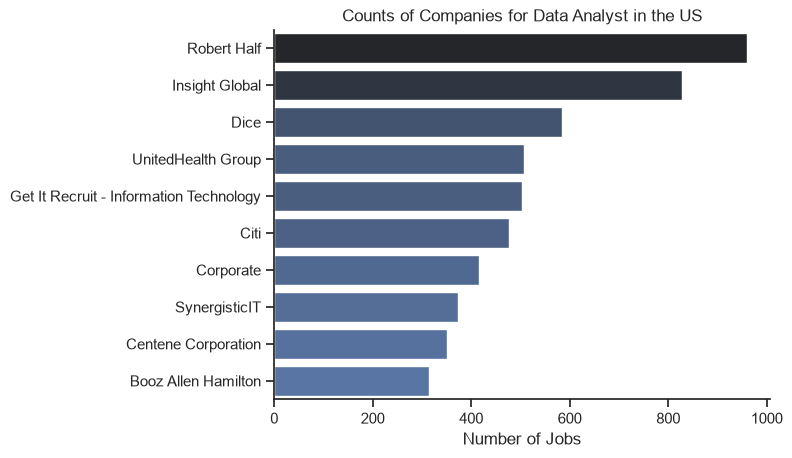

In [19]:
df_plot = df_DA_US['company_name'].value_counts().to_frame().head(10)
sns.set_theme(style='ticks')
sns.barplot(data=df_plot, x='count', y='company_name', hue='count', palette='dark:b_r', legend=False)
sns.despine()
plt.title('Counts of Companies for Data Analyst in the US')
plt.xlabel('Number of Jobs')
plt.ylabel('')
plt.show()
